# Image Classification: Cats vs Dogs
## 1. Import Packages

In [17]:
import os
import numpy as np

import torch
import torch.nn as nn
import torchvision
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

## 2. Pre-Produce

In [18]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [19]:
# dataset pre-produce class
classes = {0:"dog", 1:"cat"}
class MyDataset(Dataset):
    def __init__(self, data_path, transform=None):
        self.data_path = data_path
        if transform is None:
            self.transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                transforms.Resize((128,128))
            ])
        else:
            self.transform = transform
        self.img_list = os.listdir(self.data_path)
    
    # create label
    def __getitem__(self, idx):
        img_name = self.img_list[idx]
        if img_name.split('.')[0] == 'cat':
            label = 1
        else:
            label = 0
        label = torch.as_tensor(label, dtype=torch.int64)
        img_path = os.path.join(self.data_path, img_name)
        img = Image.open(img_path)
        img = self.transform(img)
        return img, label
    
    def __len__(self):
        return len(self.img_list)

## 3. Load datasets

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99970174..1.0].


(<matplotlib.image.AxesImage at 0x7f601faa5400>, torch.Size([3, 128, 128]))

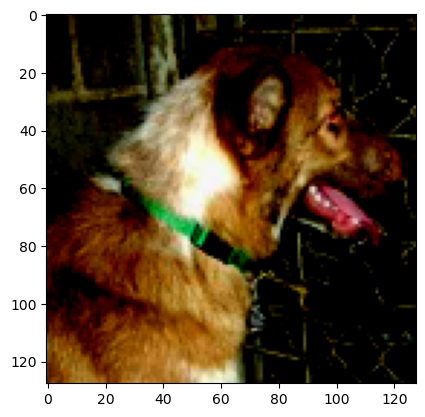

In [20]:
# load datasets
train_path = "data/train"
test_path = "data/test1"
train_set = MyDataset(train_path)
test_set = MyDataset(test_path)

# create loader
train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=True)

dataiter = iter(train_loader)
imgs, _ = next(dataiter)      
imshow(torchvision.utils.make_grid(imgs[0].permute(1,2,0))), imgs[0].shape

## 4. Nets
### DNN

In [21]:
# DNN
class DNN(nn.Module):
    def __init__(self):
        super(DNN,self).__init__() 
        self.seq = nn.Sequential(
            nn.Flatten(), # flatten all dimensions except batch from start_dim=1
            nn.Linear(3*128*128, 1024, bias=True), 
            nn.ReLU(),
            nn.Linear(1024, 512, bias=True),
            nn.ReLU(),
            nn.Linear(512, 2, bias=True),
            nn.Softmax(dim=1),
        )
        
    def forward(self, x):
        x = self.seq(x)
        return x

### CNN

In [ ]:
# CNN


### RNN

### Load Net Model

In [22]:
net = DNN().to(device)
print(net)

DNN(
  (seq): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=49152, out_features=1024, bias=True)
    (2): ReLU()
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): ReLU()
    (5): Linear(in_features=512, out_features=2, bias=True)
    (6): Softmax(dim=1)
  )
)


## 5. Optimizer and Loss Function

In [23]:
# create optimizer
optimizer = torch.optim.SGD(net.parameters(), lr=1e-3, momentum=0.9)

# create loss
loss_func = nn.CrossEntropyLoss()

## 6. Train

In [24]:
# train
epochs = 10
N = 5
loss_list = []
for epoch in range(epochs):
    loss_list.append([])
loss_accumulate = 0.0
# set train mode
net.train()
# start train
print("Start Training...")
for epoch in range(epochs):
    print(f"epoch: {epoch}")
    for i, (inputs, labels) in enumerate(train_loader):
        # get the inputs; data in train_loader is a mini-batch of [inputs, labels]
        inputs, labels = inputs.to(device), labels.to(device)
        # zero the parameter gradients
        optimizer.zero_grad()
        # forward
        outputs = net(inputs)
        # loss compute
        loss = loss_func(outputs, labels)
        # backward
        loss.backward()
        # update
        optimizer.step()
        
        # for plot
        # progress bar drawing control
        left_length_ratio = (i+1)/len(train_loader)
        right_length_ratio = 1.0-left_length_ratio
        bar_length = 50
        # accumulate loss of every 1000 mini-batches
        loss_accumulate += loss.item()
        if i % N == N-1: # record avg loss every N mini-batches
            loss_list[epoch].append(loss_accumulate/N)
            loss_accumulate = 0.0
        print(f'\r{100*(i+1)//len(train_loader):3d}% [', 
              f'▓'*int(left_length_ratio*bar_length), 
              ' '*int(right_length_ratio*bar_length), 
              f'] {(i+1):3d}/{len(train_loader):3d}', 
              end='\r')
    
    print(f'\n epoch {epoch} last mini-batch loss: {loss_list[epoch][-1]:.3f}')

     
print("Finished Training.")

Start Training...
epoch: 0
100% [ ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓  ] 782/782
 epoch 0 last mini-batch loss: 0.660
epoch: 1
100% [ ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓  ] 782/782
 epoch 1 last mini-batch loss: 0.631
epoch: 2
100% [ ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓  ] 782/782
 epoch 2 last mini-batch loss: 0.614
epoch: 3
100% [ ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓  ] 782/782
 epoch 3 last mini-batch loss: 0.614
epoch: 4


KeyboardInterrupt: 

In [ ]:
# plot
plt.plot(np.arange(1, len(loss_list[epoch])+1), loss_list[epoch])
plt.title(f"epoch={epochs-1}, train loss")

In [ ]:
# save model
save_path = f'model/{net._get_name()}.pth'
torch.save(net.state_dict(), save_path)

## 7. Test

In [ ]:
# test
# load model
load_path = f'model/{net._get_name()}.pth'
net.load_state_dict(torch.load(load_path))
print(net.state_dict()['seq.1.weight'])

In [ ]:
# compute accuracy
correct = 0
total = 0
# set evaluate mode
net.eval()
with torch.no_grad():
    for i, (images, labels) in enumerate(tqdm(test_loader)):
        images = images.to(device)
        labels = labels.to(device)
        y_hats = net(images)
        _, predicted = torch.max(y_hats.data, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the {total} test images: {100 * correct // total} %')